# Exp7.2.3 — Objective × Temporal Head × Output Dynamics
Analysis-only notebook. It reads finalized summary CSVs and never trains, evaluates checkpoints, or displays individual runs.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists(): ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_3_objective_temporal_dynamics' / 'objective_temporal_dynamics_v1'
architecture = pd.read_csv(ART / 'architecture_table.csv')
performance = pd.read_csv(ART / 'performance_summary.csv')
representation = pd.read_csv(ART / 'representation_probe_summary.csv')
deltas = pd.read_csv(ART / 'paired_delta_summary.csv')
dynamics = pd.read_csv(ART / 'output_dynamics_summary.csv')
architecture

,architecture,L1_shifts,L2_shifts
0,234x234,2-3-4,2-3-4
1,34x345,3-4,3-4-5


## Figure 1 — Objective × temporal head

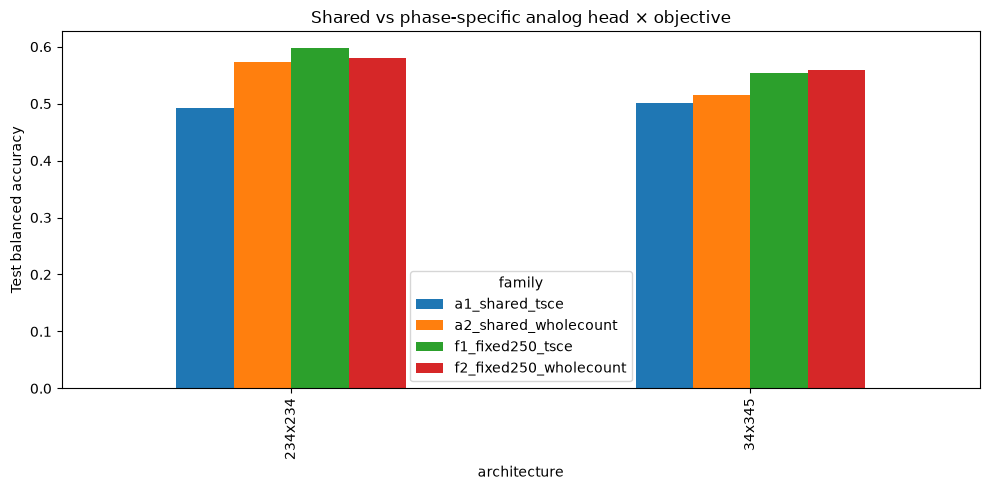

In [2]:
analog = performance[(performance['split']=='test') & (performance['source']=='native') & performance['family'].isin(['a1_shared_tsce','a2_shared_wholecount','f1_fixed250_tsce','f2_fixed250_wholecount'])]
view = analog.groupby(['architecture','family'], as_index=False)['balanced_accuracy_mean'].mean()
pivot = view.pivot(index='architecture', columns='family', values='balanced_accuracy_mean')
ax = pivot.plot(kind='bar', figsize=(10,5))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Shared vs phase-specific analog head × objective')
plt.tight_layout()

## Figure 2 — Frozen L2 temporal accessibility

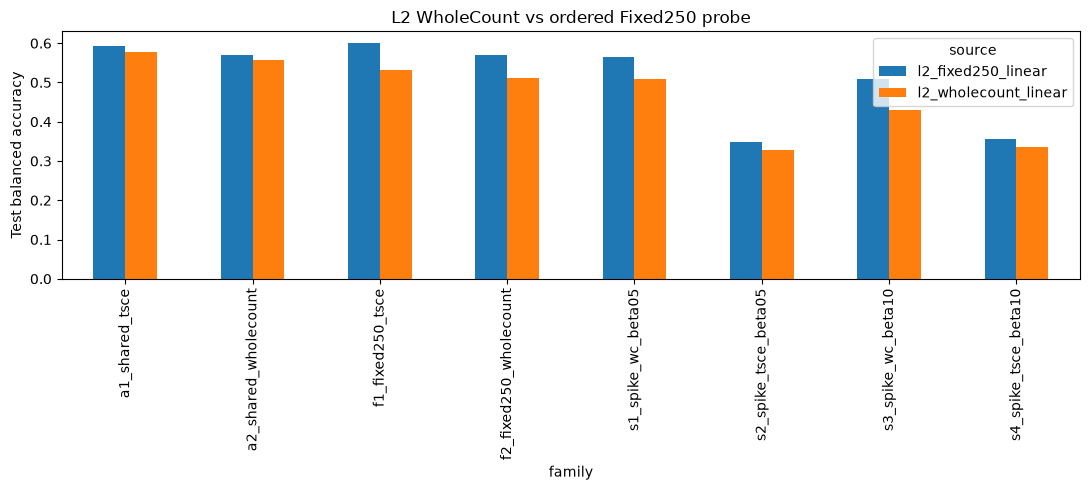

In [3]:
rep = representation[representation['split']=='test']
view = rep.groupby(['family','source'], as_index=False)['balanced_accuracy_mean'].mean()
pivot = view.pivot(index='family', columns='source', values='balanced_accuracy_mean')
ax = pivot.plot(kind='bar', figsize=(11,5))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('L2 WholeCount vs ordered Fixed250 probe')
plt.tight_layout()

## Figure 3 — Spiking output decomposition

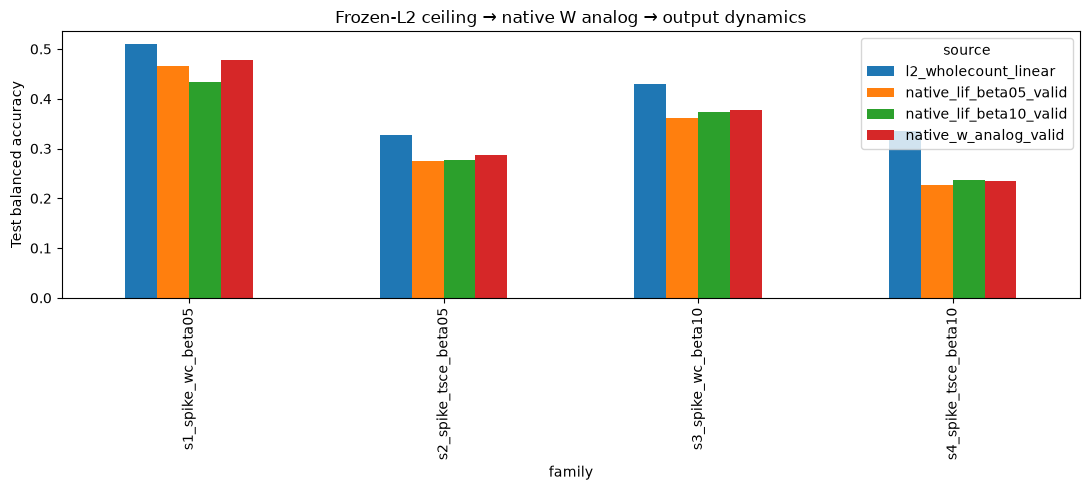

In [4]:
sources = ['l2_wholecount_linear','native_w_analog_valid','native_lif_beta05_valid','native_lif_beta10_valid']
spike = performance[(performance['split']=='test') & performance['family'].str.startswith('s') & performance['source'].isin(sources)]
view = spike.groupby(['family','source'], as_index=False)['balanced_accuracy_mean'].mean()
pivot = view.pivot(index='family', columns='source', values='balanced_accuracy_mean')
ax = pivot.plot(kind='bar', figsize=(11,5))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Frozen-L2 ceiling → native W analog → output dynamics')
plt.tight_layout()

## Figure 4 — Counterfactual beta and tail effects

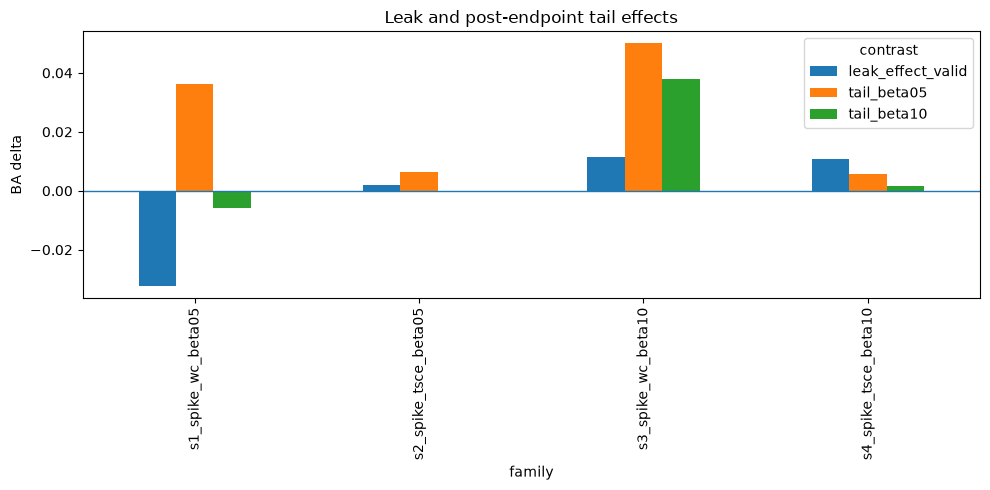

In [5]:
d = deltas[(deltas['metric']=='balanced_accuracy') & deltas['contrast'].isin(['leak_effect_valid','tail_beta05','tail_beta10'])]
view = d.groupby(['family','contrast'], as_index=False)['delta_mean'].mean()
pivot = view.pivot(index='family', columns='contrast', values='delta_mean')
ax = pivot.plot(kind='bar', figsize=(10,5))
ax.axhline(0, linewidth=1)
ax.set_ylabel('BA delta')
ax.set_title('Leak and post-endpoint tail effects')
plt.tight_layout()